In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# Load the dataset 
data = pd.read_csv("tested.csv")

# Feature Engineering

data['Title'] = data['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
data['Title'] = data['Title'].replace(['Lady', 'Countess','Capt', 'Col','Don', 'Dr', 
                                      'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
data['Title'] = data['Title'].replace('Mlle', 'Miss')
data['Title'] = data['Title'].replace('Ms', 'Miss')
data['Title'] = data['Title'].replace('Mme', 'Mrs')

# Family features
data['FamilySize'] = data['SibSp'] + data['Parch'] + 1
data['IsAlone'] = np.where(data['FamilySize'] > 1, 0, 1)

# Cabin features
data['Deck'] = data['Cabin'].str[0]
data['Deck'] = data['Deck'].fillna('Unknown')

# Age binning
data['AgeGroup'] = pd.cut(data['Age'], bins=[0, 12, 18, 35, 60, 100], 
                        labels=['Child', 'Teen', 'Young Adult', 'Adult', 'Senior'])

# Handle Missing Values
# ---------------------
# Age - median imputation
data['Age'] = data['Age'].fillna(data['Age'].median())

# Embarked - mode imputation
data['Embarked'] = data['Embarked'].fillna(data['Embarked'].mode()[0])

# Fare - median imputation (just in case)
data['Fare'] = data['Fare'].fillna(data['Fare'].median())

# Categorical Encoding
# ---------------------
# One-hot encoding
cat_features = ['Sex', 'Embarked', 'Title', 'Deck', 'AgeGroup']
data = pd.get_dummies(data, columns=cat_features, drop_first=True)

# Drop unnecessary columns
data = data.drop(['PassengerId', 'Name', 'Ticket', 'Cabin', 'Age'], axis=1)

# Split Data
X = data.drop('Survived', axis=1)
y = data['Survived']

# Split into train/test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature Scaling (optional for tree-based models)
scaler = StandardScaler()
num_features = ['Fare', 'FamilySize']
X_train[num_features] = scaler.fit_transform(X_train[num_features])
X_test[num_features] = scaler.transform(X_test[num_features])

print("Preprocessed Training Shape:", X_train.shape)
print("Available Features:", list(X_train.columns))

c:\Users\rahul\Desktop\anaconda\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Preprocessed Training Shape: (334, 24)
Available Features: ['Pclass', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'IsAlone', 'Sex_male', 'Embarked_Q', 'Embarked_S', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare', 'Deck_B', 'Deck_C', 'Deck_D', 'Deck_E', 'Deck_F', 'Deck_G', 'Deck_Unknown', 'AgeGroup_Teen', 'AgeGroup_Young Adult', 'AgeGroup_Adult', 'AgeGroup_Senior']


Model Evaluation:
-----------------
Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        53
           1       1.00      1.00      1.00        31

    accuracy                           1.00        84
   macro avg       1.00      1.00      1.00        84
weighted avg       1.00      1.00      1.00        84



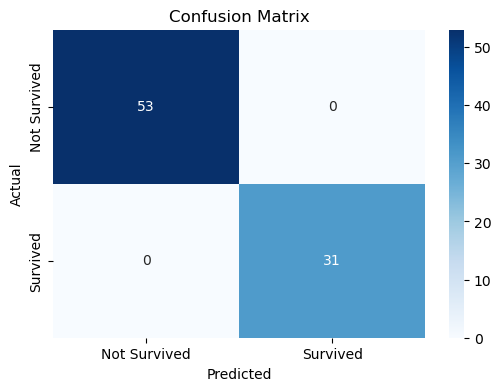

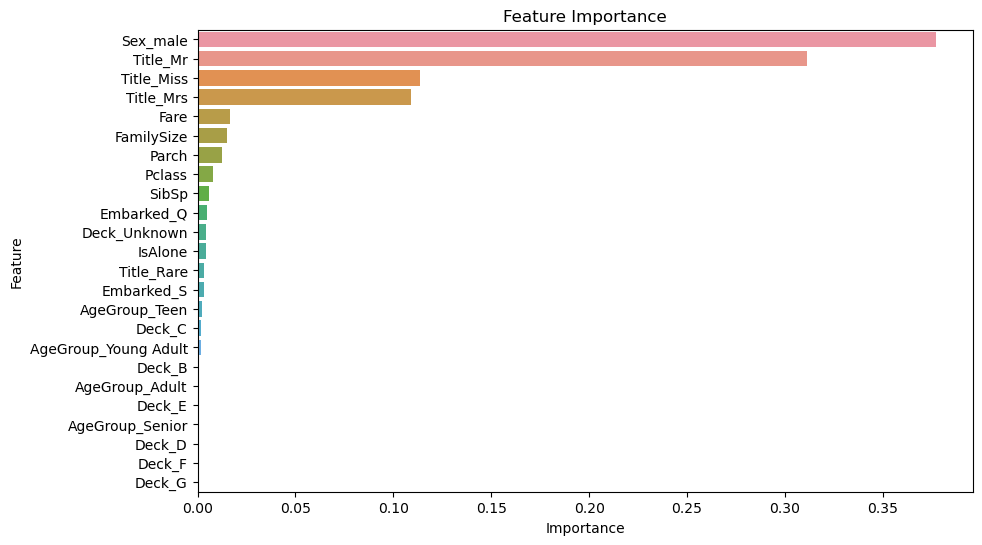


Sample Prediction:
Survival Prediction: Survived
Probability of Survival: 97.32%


In [2]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming you've already run the preprocessing code
# If not, run the previous preprocessing steps first

# Initialize Random Forest Classifier
rf_model = RandomForestClassifier(
    n_estimators=200,   # Number of trees in the forest
    max_depth=5,        # Maximum depth of trees
    min_samples_split=5, # Minimum samples required to split a node
    random_state=42,    # Seed for reproducibility
    class_weight='balanced'  # Handles class imbalance
)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions
y_pred = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]  # Probabilities for ROC curve

# Evaluate model performance
print("Model Evaluation:")
print("-----------------")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Not Survived', 'Survived'],
            yticklabels=['Not Survived', 'Survived'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

# Feature Importance
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feature_importance)
plt.title('Feature Importance')
plt.show()

# Example prediction for new data
sample_passenger = X_test.iloc[0:1]  # Take first test sample
prediction = rf_model.predict(sample_passenger)
prob = rf_model.predict_proba(sample_passenger)[0][1]

print(f"\nSample Prediction:")
print(f"Survival Prediction: {'Survived' if prediction[0] == 1 else 'Not Survived'}")
print(f"Probability of Survival: {prob:.2%}")

In [3]:
import joblib
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

# 1. Save the model
joblib.dump(rf_model, 'titanic_rf_model.pkl')

# 2. Save the scaler
joblib.dump(scaler, 'titanic_scaler.pkl')

print("Model and scaler saved successfully!")

Model and scaler saved successfully!
